In [5]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from order_fingers import TouchTracker
import sqlite3
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
from scipy import stats
import warnings
from itertools import combinations
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [6]:
db_path = "./labeled_new.sqlite"

In [7]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
),

no_gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        'No Gesture' AS gesture,
        'No Gesture' AS parent_gesture,
        s.participant_id,
        0 AS is_gesture,
        NULL  AS group_id
    FROM sensorData sd
    LEFT JOIN gesture_samples gs 
      ON gs.id = sd.id -- Check if this row was already labeled as a gesture
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    
    -- Exclude rows that were found in gesture_samples (gs.id IS NULL)
    -- Also keep your original session_task_id and 'Szenarien' filters
    WHERE gs.id IS NULL
      AND sd.session_task_id IN (
          SELECT DISTINCT session_task_id FROM preciseMarker
      )
      AND rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
-- UNION ALL
-- SELECT * FROM no_gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(db_path) as conn:
    # Use pandas to execute the query and load results into a DataFrame
    df = pd.read_sql_query(query, conn)

df.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50


In [8]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    smt.group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(db_path) as conn:
    szenarien_df = pd.read_sql_query(szenarien_query, conn)
szenarien_df.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50


In [9]:
# Print unique marker_types in szenarien_df with their respective counts
print(szenarien_df['marker_label'].value_counts())

marker_label
No Gesture                        3235
Tap and Hold                      2479
Spread Swipe                      1723
Single Swipe                      1450
Pinch Swipe                        838
Two-Finger Opposite Double Tap     629
Two-Finger Tap                     551
Two-Finger Double Tap              484
Double Tap                         367
Two-Finger Opposite Tap            315
Single Tap                          16
Name: count, dtype: int64


In [10]:
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded: 111506 rows, 26 columns


In [11]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['time_diff'] = df.groupby(['session_task_id', 'timestamp']).cumcount()
df['recordings_per_second'] = df.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df['estimated_timestamp'] = df['timestamp'] + pd.to_timedelta(df['time_diff'] / df['recordings_per_second'], unit='s')
df = df.drop(columns=['time_diff', 'recordings_per_second'])

df["timestamp_ms"] = (df["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111506 entries, 0 to 111505
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      111506 non-null  object        
 1   session_task_id         111506 non-null  object        
 2   session_task_row_index  111506 non-null  int64         
 3   timestamp               111506 non-null  datetime64[ns]
 4   button_pressed          111506 non-null  int64         
 5   motor_angle             111506 non-null  float64       
 6   touch_1_position        91124 non-null   float64       
 7   touch_1_pressure        91124 non-null   float64       
 8   touch_1_channel         91124 non-null   float64       
 9   touch_2_position        77739 non-null   float64       
 10  touch_2_pressure        77739 non-null   float64       
 11  touch_2_channel         77739 non-null   float64       
 12  touch_3_position        39265 

In [13]:
import pandas as pd
import numpy as np

# Define the columns used for each touch
TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame, tracker):
    """
    Processes a DataFrame sequentially to assign stable touch IDs and then 
    reorders the touch data columns based on those stable IDs.

    Args:
        df: The input DataFrame containing touch_N_position/pressure/channel.
        tracker: The initialized TouchTracker object (e.g., TouchTracker()).

    Returns:
        A new DataFrame with the touch columns stabilized by ID.
    """
    
    # List to store the 'matched' output from tracker.assign_ids() for each row
    all_matched_touches = []
    
    # --- 1. Sequential Processing (Extract & Assign IDs) ---
    print("Step 1/2: Running TouchTracker sequentially...")
    
    # Iterate over the rows of the DataFrame
    for index, row in df.iterrows():
        new_touches = []
        
        # Extract the touches for the current row into the required list format
        for prefix in TOUCH_PREFIXES:
            pos_col = f'{prefix}_position'
            press_col = f'{prefix}_pressure'
            chan_col = f'{prefix}_channel'
            
            # Check if the position data exists (assuming NaNs mark an inactive touch)
            if pd.notna(row[pos_col]):
                pos = row[pos_col]
                press = row[press_col]
                chan = row[chan_col]
                # The input to assign_ids is: (rel_pos, pressure, channel)
                new_touches.append((pos, press, chan))
            
        # Run the tracker's assignment function to get stable IDs
        # The result is: [(id, pos, press, chan), ...]
        matched_touches = tracker.assign_ids(new_touches)
        all_matched_touches.append(matched_touches)

    # --- 2. Stabilization (Sort by ID and Slot) ---
    print("Step 2/2: Stabilizing touch columns by ID...")
    
    # Prepare the new column names for the output DataFrame
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    
    # Prepare the list of rows for the new DataFrame
    stabilized_rows = []
    
    for matched_list in all_matched_touches:
        # Sort the matched list by the stable ID (the first element of the tuple)
        # This ensures that ID_10 always gets slotted before ID_20.
        matched_list.sort(key=lambda x: x[0]) 
        
        row_data = []
        
        for i in range(MAX_TOUCHES):
            if i < len(matched_list):
                # Touch is present: (id, pos, press, chan)
                # We want the data from indices 1, 2, 3 (pos, press, chan)
                touch_data = matched_list[i][1:]
                row_data.extend(touch_data)
            else:
                # Touch is absent: Fill with NaN
                row_data.extend([np.nan] * len(TOUCH_COLUMNS_BASE))
                
        stabilized_rows.append(row_data)

    # Create the new DataFrame with stabilized data
    stabilized_df = pd.DataFrame(stabilized_rows, index=df.index, columns=new_col_names)
    
    # Optional: Add a column for the active IDs for verification
    stabilized_df['active_ids'] = [[m[0] for m in row] for row in all_matched_touches]
    
    return stabilized_df

# --- Example of how to use it ---
# Assuming 'df' is your existing DataFrame and 'TouchTracker' is defined:
tracker = TouchTracker()
stabilized_touch_data = process_and_stabilize_touches(df.copy(), tracker)

# # Final step: Replace the old columns in your original DataFrame
# # 1. Get non-touch columns from the original df
non_touch_cols = [c for c in df.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df[non_touch_cols].copy()

# # 2. Join the non-touch columns with the new stabilized touch data
final_df = final_df.join(stabilized_touch_data)
print("Stabilization Complete.")

Step 1/2: Running TouchTracker sequentially...
Step 2/2: Stabilizing touch columns by ID...
Stabilization Complete.


Plotting 8 session_task_id groups.


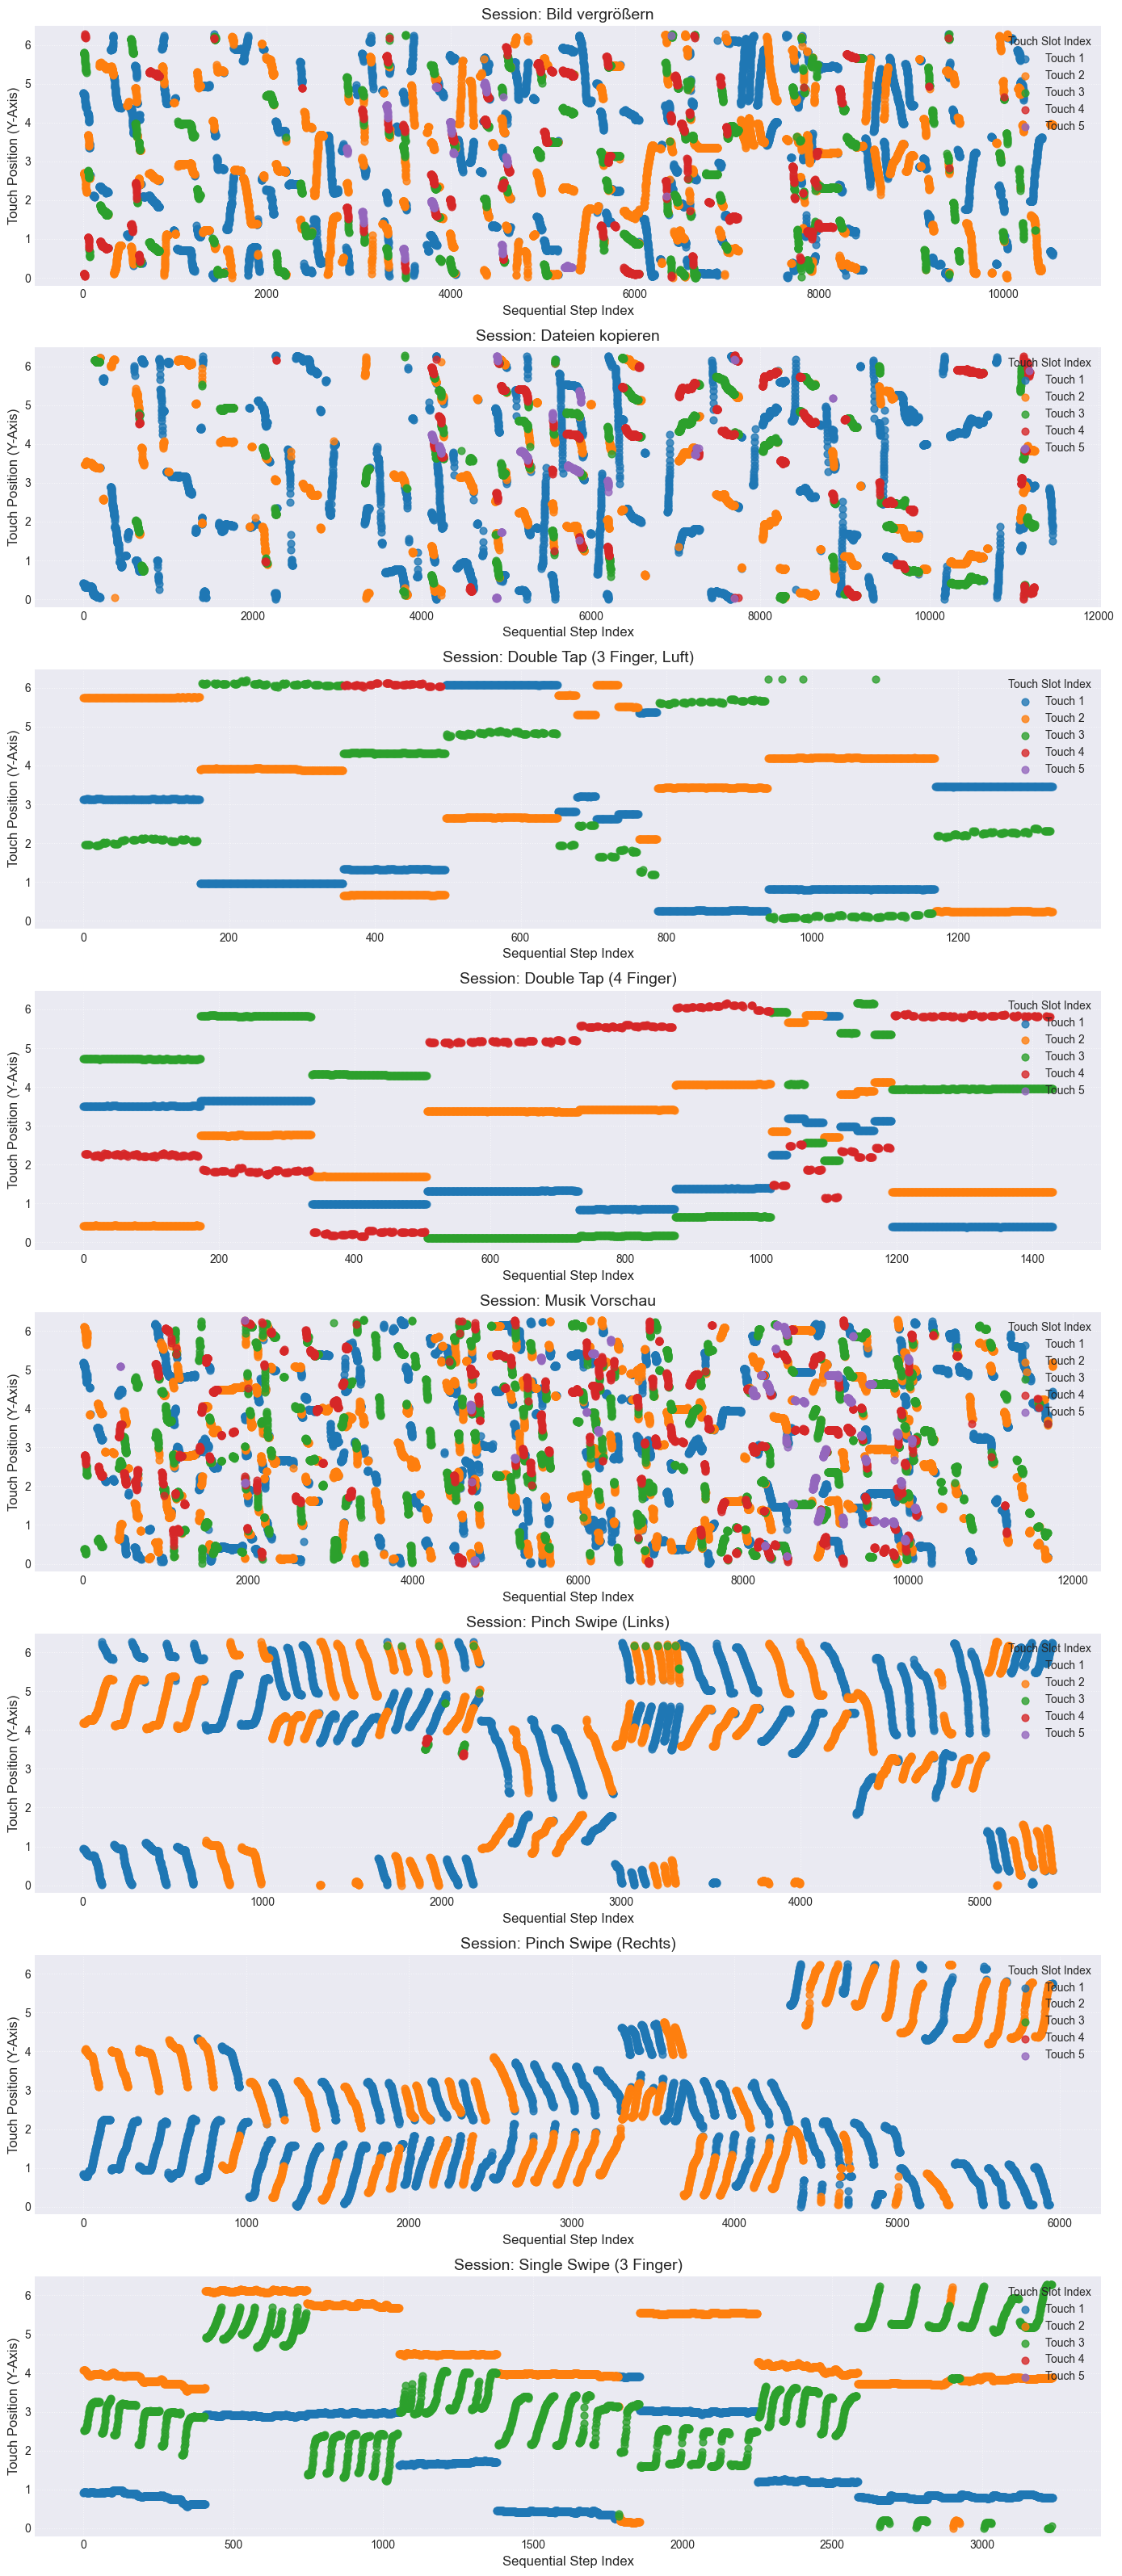

In [14]:
TOUCH_POSITION_COLS = [f'touch_{i}_position' for i in range(1, 6)]
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] 
MAX_GROUPS_TO_PLOT = 8

def plot_stabilized_touches(df_to_plot: pd.DataFrame):
    """
    Generates a scatter plot for the first 25 touch positions for each 
    session_task_id, using index for X, position for Y, and color for touch index.
    """
    
    grouped_df = df_to_plot[df_to_plot["is_gesture"] == 1].groupby('gesture')
    
    # Select only the first N groups
    plotting_groups = list(grouped_df)[:MAX_GROUPS_TO_PLOT] 
    num_groups = len(plotting_groups)
    
    if num_groups == 0:
        print("Error: The DataFrame is empty or the 'session_task_id' column is missing.")
        return

    # Set up the subplot layout
    fig, axes = plt.subplots(
        nrows=num_groups, 
        ncols=1, 
        figsize=(14, 4 * num_groups), 
        sharex=False, 
        sharey=True
    )
    
    if num_groups == 1:
        axes = np.array([axes])
        
    print(f"Plotting {num_groups} session_task_id groups.")

    # Iterate and plot
    for i, (group_id, group_data) in enumerate(plotting_groups):
        ax = axes[i]
        
        # Select the first 25 rows and reset index (0 to 24)
        subset_data = group_data.reset_index(drop=True)
        
        # Plot each touch column
        for touch_index, col in enumerate(TOUCH_POSITION_COLS):
            touch_label = f'Touch {touch_index + 1}'
            color = COLORS[touch_index]
            
            # Filter out NaNs to only plot active touches
            non_nan_data = subset_data.dropna(subset=[col])
            
            ax.scatter(
                non_nan_data.index, # X: Sequential Step Index (0, 1, 2, ...)
                non_nan_data[col],  # Y: Touch Position
                color=color,
                label=touch_label,
                s=40,
                alpha=0.8
            )

        # Configure the subplot
        ax.set_title(f'Session: {group_id}', fontsize=14)
        ax.set_xlabel(f'Sequential Step Index', fontsize=12)
        ax.set_ylabel('Touch Position (Y-Axis)', fontsize=12)
        ax.legend(title='Touch Slot Index', loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_ylim(-0.2, 2 * np.pi + 0.2)
        
    plt.tight_layout()
    plt.show()

# --- 3. EXECUTION ---
# This is the line that uses the variable name you asked for: final_df
plot_stabilized_touches(final_df)

Plotting 8 session_task_id groups.


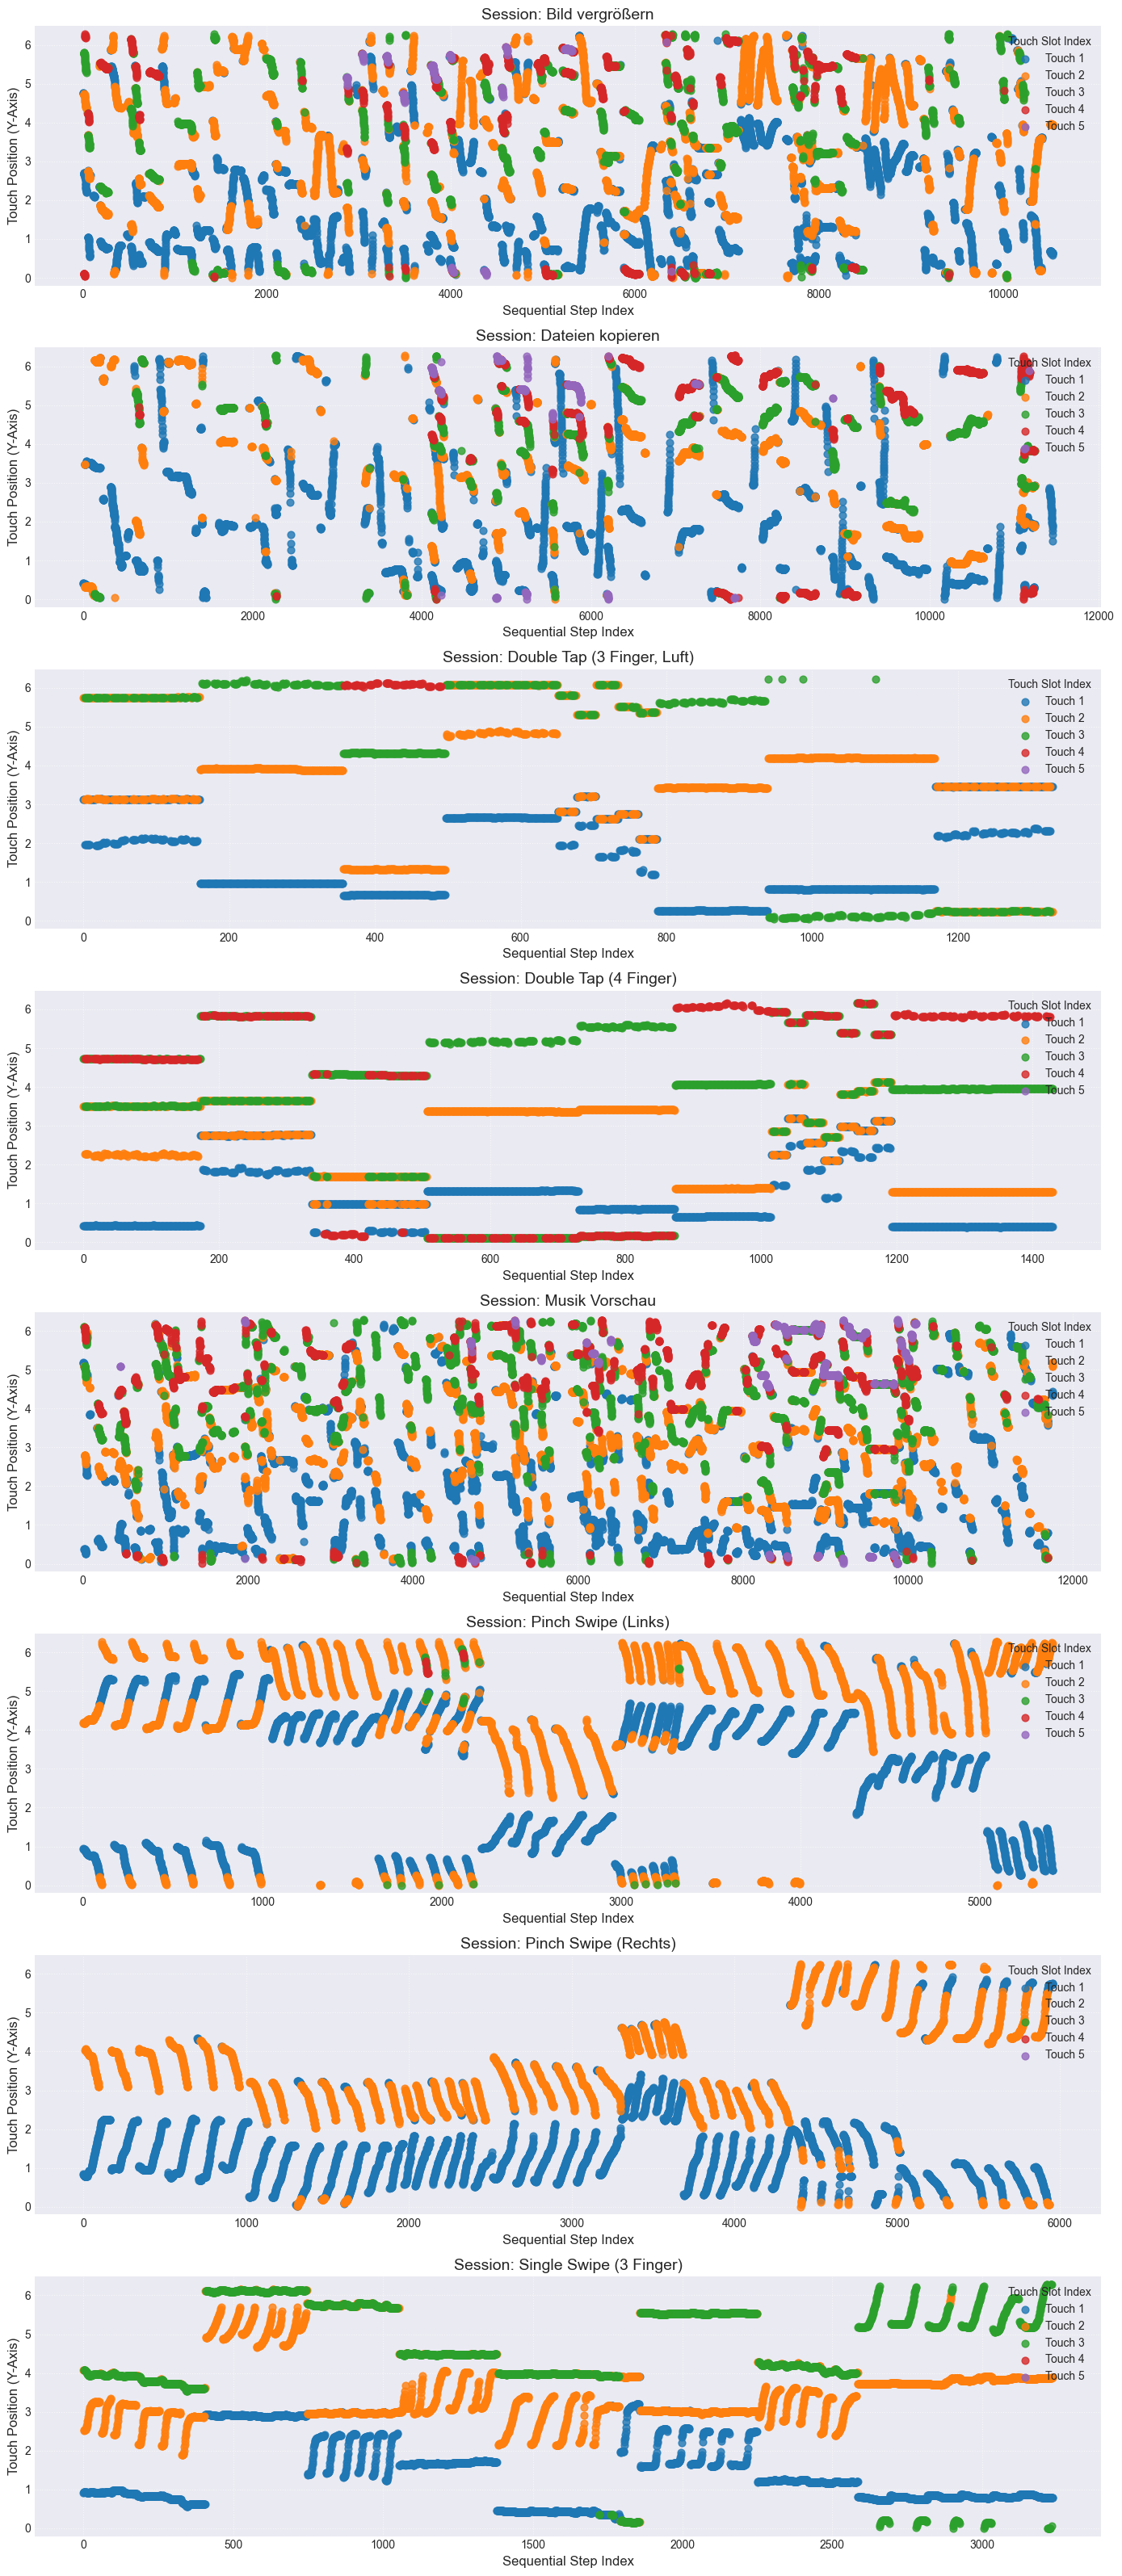

In [15]:
plot_stabilized_touches(df)

In [16]:
old_df = df.copy()
df = final_df.copy()

In [17]:
df.describe()

,session_task_row_index,timestamp,button_pressed,motor_angle,is_gesture,estimated_timestamp,timestamp_ms,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel
count,111506.000000,111506,111506.000000,111506.000000,111506.000000,111506,1.115060e+05,91124.000000,91124.000000,91124.000000,77739.000000,77739.000000,77739.000000,39265.000000,39265.000000,39265.000000,13696.000000,13696.000000,13696.000000,3155.000000,3155.000000,3155.000000
mean,1638.943582,2025-11-15 17:03:45.266281472,0.017111,121.557357,0.767134,2025-11-15 17:03:45.753896448,1.763226e+12,2.824318,995.581000,3.622635,3.180305,1023.052226,3.644567,3.045917,1061.898536,3.718299,3.545334,899.923262,3.441589,3.380281,723.468146,3.060222
min,0.000000,2025-10-03 15:35:07,0.000000,-4.239540,0.000000,2025-10-03 15:35:07,1.759506e+12,0.000082,41.000000,1.000000,0.000102,41.000000,1.000000,0.000342,41.000000,1.000000,0.000451,41.000000,1.000000,0.002335,41.000000,1.000000
25%,749.000000,2025-10-03 16:46:15,0.000000,47.936901,1.000000,2025-10-03 16:46:15.963333376,1.759510e+12,1.111408,538.000000,3.000000,1.621255,569.000000,3.000000,1.575556,674.000000,3.000000,2.015921,551.000000,3.000000,1.924265,426.000000,3.000000
50%,1338.000000,2025-10-07 14:12:18,0.000000,113.382660,1.000000,2025-10-07 14:12:18.480769280,1.759846e+12,2.837065,884.000000,4.000000,3.355553,961.000000,4.000000,3.184906,1006.000000,4.000000,3.817208,848.000000,3.000000,3.734478,648.000000,3.000000
75%,2195.000000,2025-12-29 10:20:07,0.000000,184.305496,1.000000,2025-12-29 10:20:07.343333376,1.767004e+12,4.235571,1308.000000,4.000000,4.516671,1367.000000,4.000000,4.427034,1422.000000,4.000000,5.274045,1223.000000,4.000000,4.753667,992.000000,4.000000
max,7416.000000,2026-01-06 16:07:00,1.000000,320.797974,1.000000,2026-01-06 16:07:00.984126984,1.767716e+12,6.282874,4813.000000,11.000000,6.282836,4864.000000,11.000000,6.282947,3013.000000,9.000000,6.282195,2706.000000,7.000000,6.281097,2330.000000,6.000000
std,1227.176543,NaN,0.129686,88.380746,0.422660,NaN,3.835354e+09,1.810231,626.872434,1.171023,1.820616,596.893999,1.091813,1.786516,519.883142,0.924502,1.855058,485.095029,0.991504,1.751617,429.554050,0.954341


In [18]:
# Check the distribution of is_gesture
print("\nCLASS DISTRIBUTION:")
class_counts = df['is_gesture'].value_counts().sort_index()
print(class_counts)

total_samples = len(df)
print(f"\nTotal samples: {total_samples:,}")

# Calculate percentages
for label in [0, 1]:
    count = class_counts.get(label, 0)
    percentage = (count / total_samples) * 100
    class_name = "No Gesture" if label == 0 else "Gesture"
    print(f"  {class_name} (is_gesture={label}): {count:,} samples ({percentage:.2f}%)")

# Calculate imbalance ratio
gesture_count = class_counts.get(1, 0)
no_gesture_count = class_counts.get(0, 0)

if gesture_count > 0:
    imbalance_ratio = no_gesture_count / gesture_count
    print(f"\n Ratio: {imbalance_ratio:.2f}:1")
    print(f"   (No-Gesture : Gesture)")


CLASS DISTRIBUTION:
is_gesture
0    25966
1    85540
Name: count, dtype: int64

Total samples: 111,506
  No Gesture (is_gesture=0): 25,966 samples (23.29%)
  Gesture (is_gesture=1): 85,540 samples (76.71%)

 Ratio: 0.30:1
   (No-Gesture : Gesture)


In [19]:
print("\nGesture distribution (for gestures):")
parent_breakdown = df[df['is_gesture'] == 1].groupby('parent_gesture').size().sort_values(ascending=False)
for parent_name, count in parent_breakdown.items():
    percentage = (count / gesture_count) * 100
    print(f"  {parent_name}: {count:,} samples ({percentage:.1f}%)")



Gesture distribution (for gestures):
  Szenarien: 33,808 samples (39.5%)
  Tap and Hold: 11,985 samples (14.0%)
  Pinch Swipe: 11,370 samples (13.3%)
  Spread Swipe: 9,049 samples (10.6%)
  Single Swipe: 6,072 samples (7.1%)
  Two-Finger Opposite Double Tap: 2,929 samples (3.4%)
  Two-Finger Double Tap: 2,859 samples (3.3%)
  Double Tap: 2,762 samples (3.2%)
  Two-Finger Opposite Tap: 1,719 samples (2.0%)
  Two-Finger Tap: 1,610 samples (1.9%)
  Single Tap: 1,377 samples (1.6%)


In [20]:
SAMPLING_RATE_HZ = 70
WINDOW_SIZE_MS = 450
WINDOW_OVERLAP_PERCENT = 90

GESTURE_PERCENTAGE_THRESHOLD = 0.1 # 10% of samples in window must be gesture to label window as gesture

WINDOW_SIZE_SAMPLES = int((WINDOW_SIZE_MS / 1000) * SAMPLING_RATE_HZ)
STEP_SIZE_SAMPLES = int(WINDOW_SIZE_SAMPLES * (1 - WINDOW_OVERLAP_PERCENT / 100))

print(f"\nWINDOW PARAMETERS:")
print(f"  • Sampling rate: {SAMPLING_RATE_HZ} Hz")
print(f"  • Window size: {WINDOW_SIZE_MS} ms ({WINDOW_SIZE_SAMPLES} samples)")
print(f"  • Window overlap: {WINDOW_OVERLAP_PERCENT}%")
print(f"  • Step size: {STEP_SIZE_SAMPLES} samples")
print(f"  • Updates per second: {1000 / (STEP_SIZE_MS := STEP_SIZE_SAMPLES/SAMPLING_RATE_HZ*1000):.1f}")
print(f"  • Samples needed to label window as gesture: {int(np.ceil(WINDOW_SIZE_SAMPLES * GESTURE_PERCENTAGE_THRESHOLD))} samples ({GESTURE_PERCENTAGE_THRESHOLD*100:.1f}%)")


WINDOW PARAMETERS:
  • Sampling rate: 70 Hz
  • Window size: 450 ms (31 samples)
  • Window overlap: 90%
  • Step size: 3 samples
  • Updates per second: 23.3
  • Samples needed to label window as gesture: 4 samples (10.0%)


In [21]:
# Same sensor columns as main pipeline
SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]


In [22]:
df_binary = df.copy()
df_binary['timestamp'] = pd.to_datetime(df_binary['timestamp'])
df_binary = df_binary.sort_values(['session_task_id', 'timestamp']).reset_index(drop=True)

# Handle missing values
for col in SENSOR_COLUMNS:
    if col in df_binary.columns:
        df_binary[col] = df_binary.groupby('session_task_id')[col].fillna(method='ffill')
        df_binary[col] = df_binary.groupby('session_task_id')[col].fillna(method='bfill')

df_binary[SENSOR_COLUMNS] = df_binary[SENSOR_COLUMNS].fillna(0)
df_binary['button_pressed'] = df_binary['button_pressed'].astype(int)

In [23]:
def create_sliding_windows_binary(session_df, window_size, step_size):
    session_df = session_df.sort_values('timestamp').reset_index(drop=True)
    sensor_data = session_df[SENSOR_COLUMNS].values
    binary_labels = session_df['is_gesture'].values
    
    n_samples = len(sensor_data)
    windows = []
    window_labels = []
    window_metadata = []
    
    for start_idx in range(0, n_samples - window_size + 1, step_size):
        end_idx = start_idx + window_size
        
        window = sensor_data[start_idx:end_idx]
        window_label_segment = binary_labels[start_idx:end_idx]

        # MAJORITY VOTING: If >50% of window contains gesture, label as gesture
        # For binary detector, we want high recall, so even small gesture presence counts
        gesture_percentage = np.mean(window_label_segment)
        
        # Threshold: if >30% of window is gesture, label as gesture
        # This makes detector more sensitive (fewer false negatives)
        window_label = 1 if gesture_percentage > GESTURE_PERCENTAGE_THRESHOLD else 0
        
        windows.append(window)
        window_labels.append(window_label)
        window_metadata.append({
            'session_task_id': session_df['session_task_id'].iloc[0],
            'participant_id': session_df['participant_id'].iloc[0],
            'start_idx': start_idx,
            'end_idx': end_idx,
            'gesture_percentage': gesture_percentage
        })
    
    return np.array(windows), np.array(window_labels), window_metadata


# Apply to all sessions
all_windows = []
all_labels = []
all_metadata = []

session_groups = df_binary.groupby('session_task_id')
total_sessions = len(session_groups)

print(f"Processing {total_sessions} sessions...")

for idx, (session_id, session_df) in enumerate(session_groups):
    if (idx + 1) % 10 == 0:
        print(f"  Processing session {idx + 1}/{total_sessions}...")
    
    if len(session_df) >= WINDOW_SIZE_SAMPLES:  # Only process if enough samples
        windows, labels, metadata = create_sliding_windows_binary(
            session_df,
            WINDOW_SIZE_SAMPLES,
            STEP_SIZE_SAMPLES
        )
        
        all_windows.extend(windows)
        all_labels.extend(labels)
        all_metadata.extend(metadata)

# Convert to numpy arrays
X_windows = np.array(all_windows)
y_binary = np.array(all_labels)

print(f"\nWindowing complete!")
print(f"  Total windows: {len(X_windows):,}")
print(f"  Window shape: {X_windows.shape}")
print(f"  (n_windows, window_size, n_features)")

# Check final class distribution
unique, counts = np.unique(y_binary, return_counts=True)
print(f"\nWINDOW LABEL DISTRIBUTION:")
for label, count in zip(unique, counts):
    percentage = (count / len(y_binary)) * 100
    label_name = "No Gesture" if label == 0 else "Gesture"
    print(f"  {label_name}: {count:,} windows ({percentage:.1f}%)")

window_ratio = counts[0] / counts[1] if len(counts) > 1 else 0
print(f"  Window ratio: {window_ratio:.2f}:1")


Processing 227 sessions...
  Processing session 10/227...
  Processing session 20/227...
  Processing session 30/227...
  Processing session 40/227...
  Processing session 50/227...
  Processing session 60/227...
  Processing session 70/227...
  Processing session 80/227...
  Processing session 90/227...
  Processing session 100/227...
  Processing session 110/227...
  Processing session 120/227...
  Processing session 130/227...
  Processing session 140/227...
  Processing session 150/227...
  Processing session 160/227...
  Processing session 170/227...
  Processing session 180/227...
  Processing session 190/227...
  Processing session 200/227...
  Processing session 210/227...
  Processing session 220/227...

Windowing complete!
  Total windows: 34,981
  Window shape: (34981, 31, 17)
  (n_windows, window_size, n_features)

WINDOW LABEL DISTRIBUTION:
  No Gesture: 8,193 windows (23.4%)
  Gesture: 26,788 windows (76.6%)
  Window ratio: 0.31:1


In [24]:
def extract_complex_features(window):
    features = []
    
    # Assume sensor column order from SENSOR_COLUMNS
    # Indices: button=0, motor=1, touch_pos=[2,5,8,11,14], touch_press=[3,6,9,12,15]
    button_col = 0
    motor_col = 1
    touch_pressure_cols = [3, 6, 9, 12, 15]  # touch_X_pressure indices
    touch_position_cols = [2, 5, 8, 11, 14]  # touch_X_position indices

    button_press_data = window[:, button_col]
    motor_data = window[:, motor_col]
    touch_pressures = window[:, touch_pressure_cols]
    touch_positions = window[:, touch_position_cols]

    # A 1 signalizes the button was pressed, this can happen multiple times in a window, so we first have to extract each consecutive time a button was pressed, plus the amount of samples for each time
    binary_button_press = (button_press_data > 0).astype(int)
    padded_button_press = np.concatenate(([0], binary_button_press, [0]))
    button_press_diff = np.diff(padded_button_press)
    button_press_starts = np.where(button_press_diff == 1)[0]
    button_press_ends = np.where(button_press_diff == -1)[0]
    button_press_durations = button_press_ends - button_press_starts

    def circular_range(angles):
        # 1. Sort the angles
        sorted_angles = np.sort(angles)
        # 2. Calculate gaps between neighbors
        gaps = np.diff(sorted_angles)
        # 3. Calculate the wrap-around gap (last to first)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        # 4. Combine all gaps
        all_gaps = np.append(gaps, wrap_gap)
        # 5. Range is the full circle minus the biggest empty space
        return 2 * np.pi - np.max(all_gaps)

    # Button Features
    # 1. Button pressed at all?
    features.append(np.any(binary_button_press))
    # 2. How often was the button pressed (changed from 0 to 1 and vice versa) and how often was it let go
    features.append(len(button_press_starts))
    features.append(len(button_press_ends))
    # 3. Mean (raw + durations)
    features.append(np.mean(binary_button_press))
    features.append(np.mean(button_press_durations) if len(button_press_durations) > 0 else 0)
    # 4. Std Dev (raw + durations)
    features.append(np.std(binary_button_press))
    features.append(np.std(button_press_durations) if len(button_press_durations) > 0 else 0)
    # 5. Median (raw + durations)
    features.append(np.median(binary_button_press))
    features.append(np.median(button_press_durations) if len(button_press_durations) > 0 else 0)
    # 6. Max duration
    features.append(np.max(button_press_durations) if len(button_press_durations) > 0 else 0)
    # 7. Min duration
    features.append(np.min(button_press_durations) if len(button_press_durations) > 0 else 0)
    # 8. Range duration
    features.append(circular_range(button_press_durations) if len(button_press_durations) > 0 else 0)
    # 9. Total duration
    features.append(np.sum(button_press_durations) if len(button_press_durations) > 0 else 0)

    # Motor Angle Features
    # 1. Mean
    features.append(np.mean(motor_data))
    # 2. Std Dev
    features.append(np.std(motor_data))
    # 3. Min Max
    features.append(np.min(motor_data))
    features.append(np.max(motor_data))
    # 4. Range
    features.append(circular_range(motor_data))
    # 5. Median
    features.append(np.median(motor_data))
    # 6. Q25 / Q75
    features.append(np.percentile(motor_data, 25))
    features.append(np.percentile(motor_data, 75))
    # 7. Skewness / Kurtosis
    features.append(stats.skew(motor_data))
    features.append(stats.kurtosis(motor_data))
    # 8. Velocity
    if len(motor_data) > 1:
        motor_velocity = np.diff(motor_data) * SAMPLING_RATE_HZ
        features.append(np.mean(motor_velocity))
        features.append(np.std(motor_velocity))
        features.append(np.max(motor_velocity))
    else:
        features.append(0)
        features.append(0)
        features.append(0)
    # 9. Acceleration
    if len(motor_data) > 2:
        motor_acceleration = np.diff(motor_data, n=2) * (SAMPLING_RATE_HZ ** 2)
        features.append(np.mean(motor_acceleration))
        features.append(np.std(motor_acceleration))
        features.append(np.max(motor_acceleration))
    else:
        features.append(0)
        features.append(0)
        features.append(0)
    # 10. Zero Crossings
    motor_mean = np.mean(motor_data)
    zero_crossings = np.where(np.diff(np.sign(motor_data - motor_mean)))[0]
    features.append(len(zero_crossings))
    # 11. Auto Correlation
    if len(motor_data) > 1:
        motor_autocorr = np.correlate(motor_data - motor_mean, motor_data - motor_mean, mode='full')
        motor_autocorr = motor_autocorr[motor_autocorr.size // 2:]
        features.append(np.max(motor_autocorr))
    else:
        features.append(0)

    # General Touch Activity Features
    # 1. Max simultaneous touches
    active_touches = (touch_pressures > 0).astype(int)
    features.append(np.max(np.sum(active_touches, axis=1)))
    # 2. Avg active touches
    features.append(np.mean(np.sum(active_touches, axis=1)))
    # 3. Any touch at all?
    features.append(np.any(active_touches))
    # 4. Total pressure across all sensors
    features.append(np.sum(touch_pressures))
    # 5. Max pressure
    features.append(np.max(touch_pressures))
    # 6. Touch centroid
    touch_position_sin_mean = np.sin(touch_positions).mean()
    touch_position_cos_mean = np.cos(touch_positions).mean()
    touch_position_mean_angle = np.arctan2(touch_position_sin_mean, touch_position_cos_mean)
    features.append(touch_position_mean_angle % (2 * np.pi))
    # 7. Touch Spread
    touch_position_R = np.sqrt(touch_position_sin_mean**2 + touch_position_cos_mean**2)
    features.append(1 - touch_position_R)
    features.append(np.sqrt(-2 * np.log(np.clip(touch_position_R, 1e-9, 1.0))))

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    for p1, p2 in combinations(touch_position_cols, 2):
        finger1_positions = window[:, p1]
        finger2_positions = window[:, p2]

        distances = short_dist(finger1_positions, finger2_positions)
        features.append(np.mean(distances))
        features.append(np.std(distances))
        features.append(np.max(distances))
        features.append(np.min(distances))
        features.append(circular_range(distances))

    # Per Finger Features
    TOUCH_MOVE_THRESHOLD = 0.05  # Radians
    for i, (pos_col, press_col) in enumerate(zip(touch_position_cols, touch_pressure_cols)):
        finger_positions = window[:, pos_col]
        finger_pressures = window[:, press_col]

        # Fill nan with 0
        finger_positions = np.nan_to_num(finger_positions, nan=0.0)
        finger_pressures = np.nan_to_num(finger_pressures, nan=0.0)

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        features.append(np.any(is_touching))
        # 2. Is continuously pressed during the window?
        features.append(np.all(finger_pressures > 0))
        # 3. Has moved? (this has a threshold to avoid noise)
        position_diff = np.abs(np.diff(finger_positions))
        features.append(np.any(position_diff > TOUCH_MOVE_THRESHOLD))

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts
        # 4. How many times was the finger touched?
        features.append(len(touch_starts))
        features.append(len(touch_ends))
        # 5. Mean touch duration
        features.append(np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        features.append(np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        features.append(np.max(touch_durations) if len(touch_durations) > 0 else 0)
        # 8. Min touch duration
        features.append(np.min(touch_durations) if len(touch_durations) > 0 else 0)
        # 9. Range touch duration
        features.append(circular_range(touch_durations) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        features.append(np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data in [finger_positions, finger_pressures]:
            # 1. Mean pressure
            features.append(np.mean(data))
            # 2. Std Dev pressure
            features.append(np.std(data))
            # 3. Max pressure
            features.append(np.max(data))
            # 4. Min pressure
            features.append(np.min(data))
            # 5. Range pressure
            features.append(circular_range(data))
            # 6. Median pressure
            features.append(np.median(data))
            # 7. Q25 / Q75
            features.append(np.percentile(data, 25))
            features.append(np.percentile(data, 75))
            # 8. Skewness / Kurtosis
            features.append(stats.skew(data))
            features.append(stats.kurtosis(data))
            # 9. Velocity
            if len(data) > 1:
                pressure_velocity = np.diff(data) * SAMPLING_RATE_HZ
                features.append(np.mean(pressure_velocity))
                features.append(np.std(pressure_velocity))
                features.append(np.max(pressure_velocity))
            else:
                features.append(0)
                features.append(0)
                features.append(0)
            # 10. Acceleration
            if len(data) > 2:
                pressure_acceleration = np.diff(data, n=2) * (SAMPLING_RATE_HZ ** 2)
                features.append(np.mean(pressure_acceleration))
                features.append(np.std(pressure_acceleration))
                features.append(np.max(pressure_acceleration))
            else:
                features.append(0)
                features.append(0)
                features.append(0)
            # 11. Zero Crossings
            pressure_mean = np.mean(data)
            zero_crossings = np.where(np.diff(np.sign(data - pressure_mean)))[0]
            features.append(len(zero_crossings))
            # 12. Auto Correlation
            if len(data) > 1:
                pressure_autocorr = np.correlate(data - pressure_mean, data - pressure_mean, mode='full')
                pressure_autocorr = pressure_autocorr[pressure_autocorr.size // 2:]
                features.append(np.max(pressure_autocorr))
            else:
                features.append(0)

    return np.array(features, dtype=np.float32)
        
def extract_simple_features(window):
    features = []
    
    # Assume sensor column order from SENSOR_COLUMNS
    # Indices: button=0, motor=1, touch_pos=[2,5,8,11,14], touch_press=[3,6,9,12,15]
    button_col = 0
    motor_col = 1
    touch_pressure_cols = [3, 6, 9, 12, 15]  # touch_X_pressure indices
    touch_position_cols = [2, 5, 8, 11, 14]  # touch_X_position indices
    
    # === BUTTON FEATURES (2 features) ===
    features.append(np.any(window[:, button_col]))  # Button pressed at all?
    features.append(np.mean(window[:, button_col]))  # Button press percentage
    
    # === MOTOR ANGLE FEATURES (4 features) ===
    motor_data = window[:, motor_col]
    features.append(np.max(motor_data))              # Max angle
    features.append(np.std(motor_data))              # Motion variance
    features.append(np.p2p(motor_data))              # Range (peak-to-peak)
    
    # Motion magnitude (simple velocity approximation)
    if len(motor_data) > 1:
        motion_diff = np.abs(np.diff(motor_data))
        features.append(np.sum(motion_diff))         # Total motion
    else:
        features.append(0)
    
    # === TOUCH ACTIVITY FEATURES (7 features) ===
    # Count active touches per timestep
    touch_pressures = window[:, touch_pressure_cols]
    active_touches = (touch_pressures > 0).astype(int)
    
    features.append(np.max(np.sum(active_touches, axis=1)))  # Max simultaneous touches
    features.append(np.mean(np.sum(active_touches, axis=1))) # Avg active touches
    features.append(np.any(active_touches))                  # Any touch at all?
    
    # Total pressure across all sensors
    features.append(np.sum(touch_pressures))                 # Total pressure
    features.append(np.max(touch_pressures))                 # Max pressure
    
    # Touch movement (position change)
    touch_positions = window[:, touch_position_cols]
    if len(touch_positions) > 1:
        position_diff = np.abs(np.diff(touch_positions, axis=0))
        features.append(np.sum(position_diff))               # Total touch movement
        features.append(np.max(position_diff))               # Max position jump
    else:
        features.append(0)
        features.append(0)
    
    return np.array(features, dtype=np.float32)


# Extract features for all windows
print("Extracting simple features from windows...")

import time
start_time = time.time()

X_features_simple = np.array([extract_complex_features(window) for window in X_windows])

extraction_time = time.time() - start_time
time_per_window = (extraction_time / len(X_windows)) * 1000  # ms

print(f"\n Feature extraction complete!")
print(f"  Feature matrix shape: {X_features_simple.shape}")
print(f"  Features per window: {X_features_simple.shape[1]}")
print(f"  Total extraction time: {extraction_time:.2f}s")
print(f"  Time per window: {time_per_window:.4f}ms")

print(f"\n FEATURE BREAKDOWN:")
print(f"  Button features: 2")
print(f"  Motor angle features: 4")
print(f"  Touch activity features: 7")
print(f"  TOTAL: {X_features_simple.shape[1]} simple features")


Extracting simple features from windows...

 Feature extraction complete!
  Feature matrix shape: (34981, 324)
  Features per window: 324
  Total extraction time: 220.93s
  Time per window: 6.3158ms

 FEATURE BREAKDOWN:
  Button features: 2
  Motor angle features: 4
  Touch activity features: 7
  TOTAL: 324 simple features


In [25]:
# print nan values per feature column
nan_counts = np.isnan(X_features_simple).sum(axis=0)
print("\nNaN counts per feature column:")
for i, count in enumerate(nan_counts):
    if count > 0:
        print(f"  Feature {i}: {count} NaNs")

# Replace nan values with 0
X_features_simple = np.nan_to_num(X_features_simple, nan=0.0)
print("\nNaN values replaced with 0.")


NaN counts per feature column:
  Feature 108: 1188 NaNs
  Feature 109: 1188 NaNs
  Feature 126: 1188 NaNs
  Feature 127: 1188 NaNs
  Feature 155: 3005 NaNs
  Feature 156: 3005 NaNs
  Feature 173: 2954 NaNs
  Feature 174: 2954 NaNs
  Feature 202: 15477 NaNs
  Feature 203: 15477 NaNs
  Feature 220: 15477 NaNs
  Feature 221: 15477 NaNs
  Feature 249: 25111 NaNs
  Feature 250: 25111 NaNs
  Feature 267: 25060 NaNs
  Feature 268: 25060 NaNs
  Feature 296: 31251 NaNs
  Feature 297: 31251 NaNs
  Feature 314: 31141 NaNs
  Feature 315: 31141 NaNs

NaN values replaced with 0.


In [26]:
from sklearn.model_selection import train_test_split

# 1. Create metadata DataFrame
metadata_df = pd.DataFrame(all_metadata)

# grouping_col = 'participant_id'
grouping_col = 'session_task_id'

# 2. Get unique participant IDs (the unit of splitting)
# TODO Use participants once there are more recordings
unique_dataset = metadata_df[grouping_col].unique()
print(f"Total {grouping_col}: {len(unique_dataset)}")

# 3. Split by participant ID (not session or window!)
train_dataset, test_dataset = train_test_split(
    unique_dataset,
    test_size=0.3, # Defines the percentage of participants to be in the test set
    random_state=42
)

print(f"\n Split Participants:")
print(f"  Training participants: {len(train_dataset)}")
print(f"  Test participants: {len(test_dataset)}")

# 4. Get window indices based on the participant split
# A window is 'train' if its participant ID is in the train_dataset list
train_mask = metadata_df[grouping_col].isin(train_dataset)
test_mask = metadata_df[grouping_col].isin(test_dataset)

# 5. Split data
X_train = X_features_simple[train_mask]
X_test = X_features_simple[test_mask]
y_train = y_binary[train_mask]
y_test = y_binary[test_mask]

# --- VERIFICATION & OUTPUT (Your original excellent checks) ---

print(f"\n Windows split:")
print(f"  Training windows: {len(X_train):,} ({len(X_train)/len(X_features_simple)*100:.1f}%)")
print(f"  Test windows: {len(X_test):,} ({len(X_test)/len(X_features_simple)*100:.1f}%)")

print(f"\n TRAINING SET:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    label_name = "No Gesture" if label == 0 else "Gesture"
    print(f"  {label_name}: {count:,} ({count/len(y_train)*100:.1f}%)")

print(f"\n TEST SET:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    label_name = "No Gesture" if label == 0 else "Gesture"
    print(f"  {label_name}: {count:,} ({count/len(y_test)*100:.1f}%)")

Total session_task_id: 227

 Split Participants:
  Training participants: 158
  Test participants: 69

 Windows split:
  Training windows: 24,786 (70.9%)
  Test windows: 10,195 (29.1%)

 TRAINING SET:
  No Gesture: 5,190 (20.9%)
  Gesture: 19,596 (79.1%)

 TEST SET:
  No Gesture: 3,003 (29.5%)
  Gesture: 7,192 (70.5%)


In [27]:
from sklearn.preprocessing import StandardScaler

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled using StandardScaler")
print(f"  Training mean: {X_train_scaled.mean():.4f}")
print(f"  Training std: {X_train_scaled.std():.4f}")


Features scaled using StandardScaler
  Training mean: -0.0000
  Training std: 0.9844


In [28]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"Calculated class weights:")
print(f"  No-Gesture (0): {class_weight_dict[0]:.3f}")
print(f"  Gesture (1): {class_weight_dict[1]:.3f}")
print(f"  Ratio: {class_weight_dict[1]/class_weight_dict[0]:.2f}x higher weight for gestures")

# For XGBoost
scale_pos_weight = class_weight_dict[1] / class_weight_dict[0]
print(f"\n  XGBoost scale_pos_weight: {scale_pos_weight:.3f}")


Calculated class weights:
  No-Gesture (0): 2.388
  Gesture (1): 0.632
  Ratio: 0.26x higher weight for gestures

  XGBoost scale_pos_weight: 0.265


In [29]:
# Import classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [30]:
# ============================================================
# 1. COST MODEL (ADJUST THESE!)
# ============================================================

COST_FN = 50.0   # Missing a true event is VERY bad
COST_FP = 40.0   # Extra multiclass inference is tolerable

THRESHOLDS = np.linspace(0.01, 0.99, 350)

# ============================================================
# 2. THRESHOLD OPTIMIZATION (MIN TOTAL COST)
# ============================================================

def get_best_threshold_for_min_cost(y_true, y_probs):
    best_cost = float("inf")
    best_thresh = 0.5
    best_cm = None

    for thresh in THRESHOLDS:
        y_pred = (y_probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        total_cost = COST_FN * fn + COST_FP * fp

        if total_cost < best_cost:
            best_cost = total_cost
            best_thresh = thresh
            best_cm = (tn, fp, fn, tp)

    return best_thresh, best_cost, best_cm


# ============================================================
# 3. RESULT PRINTING
# ============================================================

def print_binary_results(
    name,
    y_true,
    y_pred,
    best_params,
    best_threshold,
    inference_time_ms,
    total_cost
):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    print("-" * (len(name) + 45))
    print(f"Cost-Optimized Results for {name}")
    print(f"  Best Hyperparameters: {best_params}")
    print(f"  Optimal Threshold: {best_threshold:.4f}")

    print("\nConfusion Matrix:")
    print(f"  TN: {tn:,}")
    print(f"  FP: {fp:,}")
    print(f"  FN: {fn:,}")
    print(f"  TP: {tp:,}")

    print("\nMetrics:")
    print(f"  Recall: {recall:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  FPR: {fpr:.4f}")
    print(f"  F1: {f1:.4f}")

    print("\nCost:")
    print(f"  Total Cost: {total_cost:.2f}")
    print(f"  Cost / sample: {total_cost / len(y_true):.4f}")

    print("\nInference:")
    print(f"  Time per sample: {inference_time_ms:.4f} ms\n")


# ============================================================
# 4. CLASSIFIERS & GRIDS
# ============================================================

RANDOM_STATE_PARAMS = {'random_state': 42}
CLASS_WEIGHT_PARAMS = {'class_weight': 'balanced'}

classifiers = [
    {
        'name': 'Logistic Regression',
        'estimator': LogisticRegression(
            solver='saga',
            max_iter=2000,
            **RANDOM_STATE_PARAMS,
            **CLASS_WEIGHT_PARAMS
        ),
        'param_grid': {'C': [0.01, 0.1, 1.0, 10]},
    },
    {
        'name': 'Decision Tree',
        'estimator': DecisionTreeClassifier(
            **RANDOM_STATE_PARAMS,
            **CLASS_WEIGHT_PARAMS
        ),
        'param_grid': {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]},
    },
    {
        'name': 'Random Forest',
        'estimator': RandomForestClassifier(
            n_estimators=100,
            **RANDOM_STATE_PARAMS,
            **CLASS_WEIGHT_PARAMS
        ),
        'param_grid': {'max_depth': [None, 3, 5, 10, 15], 'n_estimators': [25, 50, 100, 150], 'min_samples_split': [2, 4, 5, 10], 'min_samples_leaf': [1, 2, 6, 8], 'criterion': ['gini', 'entropy']},
    },
    {
        'name': 'KNN',
        'estimator': KNeighborsClassifier(),
        'param_grid': {'n_neighbors': [5, 10, 20, 25], 'weights': ['uniform', 'distance']},
    },
    {
        'name': 'Gradient Boosting',
        'estimator': GradientBoostingClassifier(
            subsample=0.7,
            **RANDOM_STATE_PARAMS
        ),
        'param_grid': {'n_estimators': [25, 50, 75, 100], 'max_depth': [None, 2, 5], 'learning_rate': [0.035, 0.05]},
        'use_sample_weight': True
    },
    {
        'name': 'XGBoost',
        'estimator': XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            **RANDOM_STATE_PARAMS
        ),
        'param_grid': {
            'n_estimators': [50, 100, 150],
            'max_depth': [None, 3, 5],
            'learning_rate': [0.03, 0.05],
            'scale_pos_weight': [scale_pos_weight]
        },
        'use_sample_weight': True
    }
]

# ============================================================
# 5. TRAINING + COST-BASED SELECTION
# ============================================================

print("\nStarting Cost-Optimized Training")
print(f"COST_FN={COST_FN}, COST_FP={COST_FP}")

best_overall = {
    "name": None,
    "estimator": None,
    "params": None,
    "threshold": None,
    "cost": float("inf"),
    "inference_time_ms": None
}


for model in classifiers:
    name = model['name']
    estimator = model['estimator']
    param_grid = model['param_grid']

    fit_params = {}
    if model.get('use_sample_weight'):
        fit_params['sample_weight'] = class_weights[y_train]

    print(f"\n--- Training {name} ---")

    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='recall',  # coarse filter only
        cv=3,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train_scaled, y_train, **fit_params)

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_

    # Inference timing
    start = time.time()
    y_probs = best_estimator.predict_proba(X_test_scaled)[:, 1]
    inference_time_ms = (time.time() - start) / len(y_test) * 1000

    # Cost-optimized threshold
    best_thresh, best_cost, _ = get_best_threshold_for_min_cost(y_test, y_probs)
    y_pred = (y_probs >= best_thresh).astype(int)

    if best_cost < best_overall["cost"]:
        best_overall.update({
            "name": name,
            "estimator": best_estimator,
            "params": best_params,
            "threshold": best_thresh,
            "cost": best_cost,
            "inference_time_ms": inference_time_ms
        })

    print_binary_results(
        name=name,
        y_true=y_test,
        y_pred=y_pred,
        best_params=best_params,
        best_threshold=best_thresh,
        inference_time_ms=inference_time_ms,
        total_cost=best_cost
    )

print("\nCost-optimized evaluation complete.")

print("\n" + "=" * 60)
print("🏆 BEST GATEKEEPER MODEL (MIN TOTAL COST)")
print("=" * 60)

print(f"Model: {best_overall['name']}")
print(f"Best Hyperparameters: {best_overall['params']}")
print(f"Optimal Threshold: {best_overall['threshold']:.4f}")
print(f"Total Cost: {best_overall['cost']:.2f}")
print(f"Inference Time per Sample: {best_overall['inference_time_ms']:.4f} ms")

y_probs_best = best_overall["estimator"].predict_proba(X_test_scaled)[:, 1]
y_pred_best = (y_probs_best >= best_overall["threshold"]).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print("\nConfusion Matrix (Best Model):")
print(f"  TN: {tn:,}")
print(f"  FP: {fp:,}")
print(f"  FN: {fn:,}")
print(f"  TP: {tp:,}")

# Print True Positive Rate and False Positive Rate
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
f1 = (2 * precision * tpr) / (precision + tpr) if (precision + tpr) > 0 else 0.0
print(f"\nTrue Positive Rate (Recall): {tpr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"F1 Score: {f1:.4f}\n")



Starting Cost-Optimized Training
COST_FN=50.0, COST_FP=40.0

--- Training Logistic Regression ---
----------------------------------------------------------------
Cost-Optimized Results for Logistic Regression
  Best Hyperparameters: {'C': 10}
  Optimal Threshold: 0.0381

Confusion Matrix:
  TN: 818
  FP: 2,185
  FN: 244
  TP: 6,948

Metrics:
  Recall: 0.9661
  Precision: 0.7608
  FPR: 0.7276
  F1: 0.8512

Cost:
  Total Cost: 99600.00
  Cost / sample: 9.7695

Inference:
  Time per sample: 0.0004 ms


--- Training Decision Tree ---
----------------------------------------------------------
Cost-Optimized Results for Decision Tree
  Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2}
  Optimal Threshold: 0.0100

Confusion Matrix:
  TN: 1,060
  FP: 1,943
  FN: 887
  TP: 6,305

Metrics:
  Recall: 0.8767
  Precision: 0.7644
  FPR: 0.6470
  F1: 0.8167

Cost:
  Total Cost: 122070.00
  Cost / sample: 11.9735

Inference:
  Time per sample: 0.0003 ms


--- Training Random Forest -

In [31]:
# Test the best model with the szenarien dataset, create the windows then create features and scale them and finally predict, then check results and compare with labelled gestures


In [32]:
# Step 1: Create sliding windows
szenarien_df_binary = szenarien_df.copy()
szenarien_df_binary['timestamp'] = pd.to_datetime(szenarien_df_binary['timestamp'])
szenarien_df_binary = szenarien_df_binary.sort_values(['session_task_id', 'timestamp']).reset_index(drop=True)
# Handle missing values
for col in SENSOR_COLUMNS:
    if col in szenarien_df_binary.columns:
        szenarien_df_binary[col] = szenarien_df_binary.groupby('session_task_id')[col].fillna(method='ffill')
        szenarien_df_binary[col] = szenarien_df_binary.groupby('session_task_id')[col].fillna(method='bfill')
szenarien_df_binary[SENSOR_COLUMNS] = szenarien_df_binary[SENSOR_COLUMNS].fillna(0)
szenarien_windows = []
szenarien_window_metadata = []
session_groups_szenarien = szenarien_df_binary.groupby('session_task_id')
for session_id, session_df in session_groups_szenarien:
    if len(session_df) >= WINDOW_SIZE_SAMPLES:  # Only process if enough samples
        windows, _, metadata = create_sliding_windows_binary(
            session_df,
            WINDOW_SIZE_SAMPLES,
            STEP_SIZE_SAMPLES
        )
        szenarien_windows.extend(windows)
        szenarien_window_metadata.extend(metadata)
szenarien_X_windows = np.array(szenarien_windows)
print(f"Szenarien windows created: {szenarien_X_windows.shape}")

Szenarien windows created: (34981, 31, 17)


In [33]:
# Step 2: Extract features
szenarien_X_features = np.array([extract_complex_features(window) for window in szenarien_X_windows])
print(f"Szenarien features extracted: {szenarien_X_features.shape}")

Szenarien features extracted: (34981, 324)


In [34]:
# Step 2.1: Check for NaNs in the features
if np.isnan(szenarien_X_features).any():
    print("Warning: NaN values found in Szenarien features. Filling with zeros.")
    szenarien_X_features = np.nan_to_num(szenarien_X_features)

In [35]:
# Step 3: Scale features
szenarien_X_scaled = scaler.transform(szenarien_X_features)
print(f"Szenarien features scaled: {szenarien_X_scaled.shape}")

Szenarien features scaled: (34981, 324)


In [36]:
# Step 4: Predict with best model
szenarien_y_probs = best_overall["estimator"].predict_proba(szenarien_X_scaled)[:, 1]
szenarien_y_pred = (szenarien_y_probs >= best_overall["threshold"]).astype(int)
print(f"Szenarien predictions made: {szenarien_y_pred.shape}")

Szenarien predictions made: (34981,)


In [37]:
# Step 4: Evaluate predictions
print("\nEvaluating Szenarien Predictions:")
# Create true labels based on gesture presence in metadata
szenarien_y_true = np.array([
    1 if meta.get('gesture_percentage', 0) > GESTURE_PERCENTAGE_THRESHOLD else 0
    for meta in szenarien_window_metadata
])
tn, fp, fn, tp = confusion_matrix(szenarien_y_true, szenarien_y_pred).ravel()
print("\nConfusion Matrix (Szenarien):")
print(f"  TN: {tn:,}")
print(f"  FP: {fp:,}")
print(f"  FN: {fn:,}")
print(f"  TP: {tp:,}")
# Print True Positive Rate and False Positive Rate
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
f1 = (2 * precision * tpr) / (precision + tpr) if (precision + tpr) > 0 else 0.0
print(f"\nTrue Positive Rate (Recall): {tpr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"F1 Score: {f1:.4f}\n")


Evaluating Szenarien Predictions:

Confusion Matrix (Szenarien):
  TN: 5,858
  FP: 24,272
  FN: 64
  TP: 4,787

True Positive Rate (Recall): 0.9868
Precision: 0.1647
False Positive Rate: 0.8056
F1 Score: 0.2823

